In [ ]:
import pandas as pd
import pickle as pkl
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error
import json
import matplotlib.pyplot as plt

In [ ]:
#TODO: data in csv instead rather than pkl

# get the training and validation data
with open('../data/processed/df_tabular_train.pkl', 'rb') as f:
    df_train = pkl.load(f)

with open('../data/processed/df_tabular_validate.pkl', 'rb') as f:
    df_validate = pkl.load(f)

In [24]:
# seperate into features and target
X_train = df_train.drop(columns=['hourly_usage_kwh'])
X_validate = df_validate.drop(columns=['hourly_usage_kwh'])

y_train = df_train['hourly_usage_kwh']
y_validate = df_validate['hourly_usage_kwh']

In [ ]:
# use optuna to find optimal hyperparameters

early_stop_rounds = 10

# parameters for the XGBoost model
XGB_params = {'learning_rate': 0.1,
              'n_estimators': 200,
               'max_depth': 6,
                'min_child_weight': 3,
                'subsample': 0.75,
                'colsample_bytree': 0.75,
                'lambda': 1.0
                }

# tree based so need for scaling

In [ ]:

rgr_xgb = XGBRegressor(**XGB_params, early_stop_rounds=early_stop_rounds)
# for now maintain the rmse metric (function similar to MSE used in LSTM)
rgr_xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_validate, y_validate)])

[0]	validation_0-rmse:1076.29477	validation_1-rmse:1411.71762


c:\Users\Flynn\anaconda3\envs\dataProjects1\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:27:37] WARNING: D:\bld\xgboost-split_1770963347825\work\src\learner.cc:782: 
Parameters: { "early_stop_rounds" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[1]	validation_0-rmse:971.13455	validation_1-rmse:1284.17411
[2]	validation_0-rmse:877.12787	validation_1-rmse:1167.42535
[3]	validation_0-rmse:792.40486	validation_1-rmse:1065.89969
[4]	validation_0-rmse:717.07685	validation_1-rmse:954.84070
[5]	validation_0-rmse:648.63488	validation_1-rmse:874.67911
[6]	validation_0-rmse:587.95414	validation_1-rmse:785.82597
[7]	validation_0-rmse:532.96962	validation_1-rmse:725.20052
[8]	validation_0-rmse:484.33183	validation_1-rmse:656.60083
[9]	validation_0-rmse:441.15719	validation_1-rmse:596.79075
[10]	validation_0-rmse:402.20928	validation_1-rmse:543.42863
[11]	validation_0-rmse:367.24255	validation_1-rmse:508.92985
[12]	validation_0-rmse:336.02978	validation_1-rmse:480.64966
[13]	validation_0-rmse:308.34426	validation_1-rmse:453.84765
[14]	validation_0-rmse:284.14650	validation_1-rmse:431.18790
[15]	validation_0-rmse:262.68247	validation_1-rmse:412.27079
[16]	validation_0-rmse:243.77646	validation_1-rmse:397.24852
[17]	validation_0-rmse:227.292

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.75
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [43]:
# quick evaluation

with open('../data/processed/df_tabular_test.pkl', 'rb') as f:
    df_test = pkl.load(f)

X_test = df_test.drop(columns=['hourly_usage_kwh'])
y_test = df_test['hourly_usage_kwh']


In [44]:
# get predictions
y_pred = rgr_xgb.predict(X_test)

In [ ]:
# mean usages per client IN THE TEST DATA
mean_usages = df_test.groupby(level='client_id')['hourly_usage_kwh'].mean()

client_id
15        46.502629
20        43.611612
22        28.039547
24        31.139553
26        19.991142
           ...     
360      516.685921
365       89.098500
366       11.566019
369      826.566880
370    18675.170822
Name: hourly_usage_kwh, Length: 100, dtype: float64

In [49]:
# create frame from client ids and predictions
df_preds = pd.DataFrame(index=df_test.index, data={'y_pred': y_pred,
                                                      'y_true': y_test})

In [ ]:
# for each client compute the rmse
rmse_per_client = df_preds.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred']))

In [63]:
# get the mean normalised
nrmse_per_client = rmse_per_client/mean_usages

# create a summary dictionary
summary_dict = {
                'mean': nrmse_per_client.mean(),
                'std': nrmse_per_client.std(),
                'max': nrmse_per_client.max(),
                'min': nrmse_per_client.min(),
                }

In [74]:
# and log these, along with dataframe of predicitons

with open('../logs/XGB/nrmse_summary_stats.json', 'w') as f:
    json.dump(summary_dict, f, indent=4)

with open('../logs/XGB/nrmse_per_client.json', 'w') as f:
    json.dump(nrmse_per_client.to_list(), f, indent=4)

# save the XGB model used
rgr_xgb.save_model('../models/xgb.ubj')

# save predictions and labels for further evaluation (also gives client ids used)
df_preds.to_csv('../data/processed/XGB_preds_labels.csv')

In [80]:
rmse_per_client.index.get_level_values('client_id')

Index([ 15,  20,  22,  24,  26,  27,  34,  35,  43,  48,  49,  50,  52,  54,
        59,  61,  64,  74,  79,  83, 100, 103, 105, 119, 123, 124, 128, 132,
       136, 138, 141, 144, 147, 148, 149, 150, 151, 156, 159, 164, 165, 166,
       170, 171, 180, 185, 193, 195, 200, 203, 206, 209, 210, 216, 219, 221,
       225, 229, 231, 235, 238, 239, 240, 241, 244, 245, 246, 249, 250, 252,
       254, 255, 262, 268, 269, 270, 271, 277, 282, 292, 293, 296, 300, 303,
       304, 307, 319, 321, 327, 328, 330, 333, 336, 354, 359, 360, 365, 366,
       369, 370],
      dtype='int64', name='client_id')

In [ ]:
# a quick visualisation

client = 307

df_preds_filtered = df_preds[df_preds.index.get_level_values('client_id') == client].iloc[0:128*4]
datetimes = pd.to_datetime(df_preds_filtered.index.get_level_values('datetime'))
preds = df_preds_filtered['y_pred']
labels = df_preds_filtered['y_true']

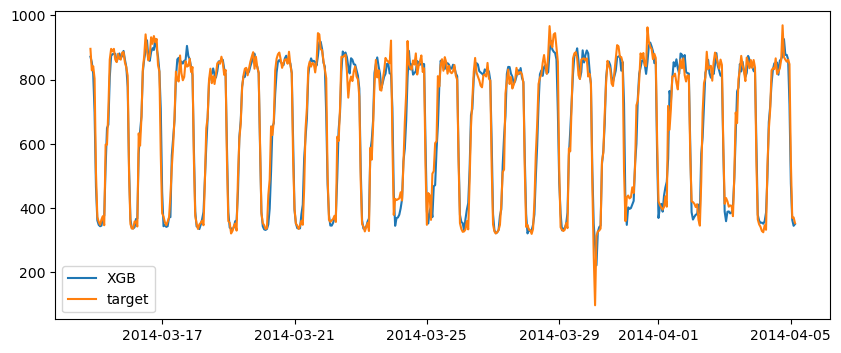

In [86]:
plt.figure(figsize=(10, 4))
plt.plot(datetimes, preds, label='XGB')
plt.plot(datetimes, labels, label='target')
plt.legend()
plt.show()